Outcome,Observed Frequency,Expected Frequency
0 Heads,24,30
1 Head,108,90
2 Heads,95,90
3 Heads,23,30



Hypotheses:
H0: The observed frequencies follow the expected distribution.
H1: The observed frequencies do not follow the expected distribution.

Chi-square Statistic: 6.711
Degrees of Freedom: 3
P-value: 0.082
Decision: Fail to Reject H0
Conclusion: The observed frequencies are consistent with the expected distribution.



Observed Frequencies:


Vaccination Status,Got Disease,Did Not Get Disease
Vaccinated,9,42
Not Vaccinated,17,28



Expected Frequencies:


...


Hypotheses:
H0: Vaccination and disease occurrence are independent.
H1: Vaccination and disease occurrence are dependent.

Chi-square Statistic: 4.906
Degrees of Freedom: 1
P-value: 0.027
Decision: Reject H0
Conclusion: Vaccination and disease occurrence are associated.


Treatment,Slept Well,Did Not Sleep Well
Sleeping Pills,44,10
Sugar Pills,81,35



Hypotheses:
H0: Sleeping pills and sleep quality are independent.
H1: Sleeping pills and sleep quality are associated.

Chi-square Statistic: 2.571
Degrees of Freedom: 1
P-value: 0.109
Decision: Fail to Reject H0
Conclusion: There is no significant relationship between sleeping pills and sleep quality.


Eye Color,Blonde,Not Blonde
Blue Eyes,49,25
Not Blue,30,96



Chi-square Statistic: 35.082
Degrees of Freedom: 1
P-value: 0.000
Coefficient of Contingency (C): 0.386

Interpretation:
There is a moderate association between eye color and hair color.


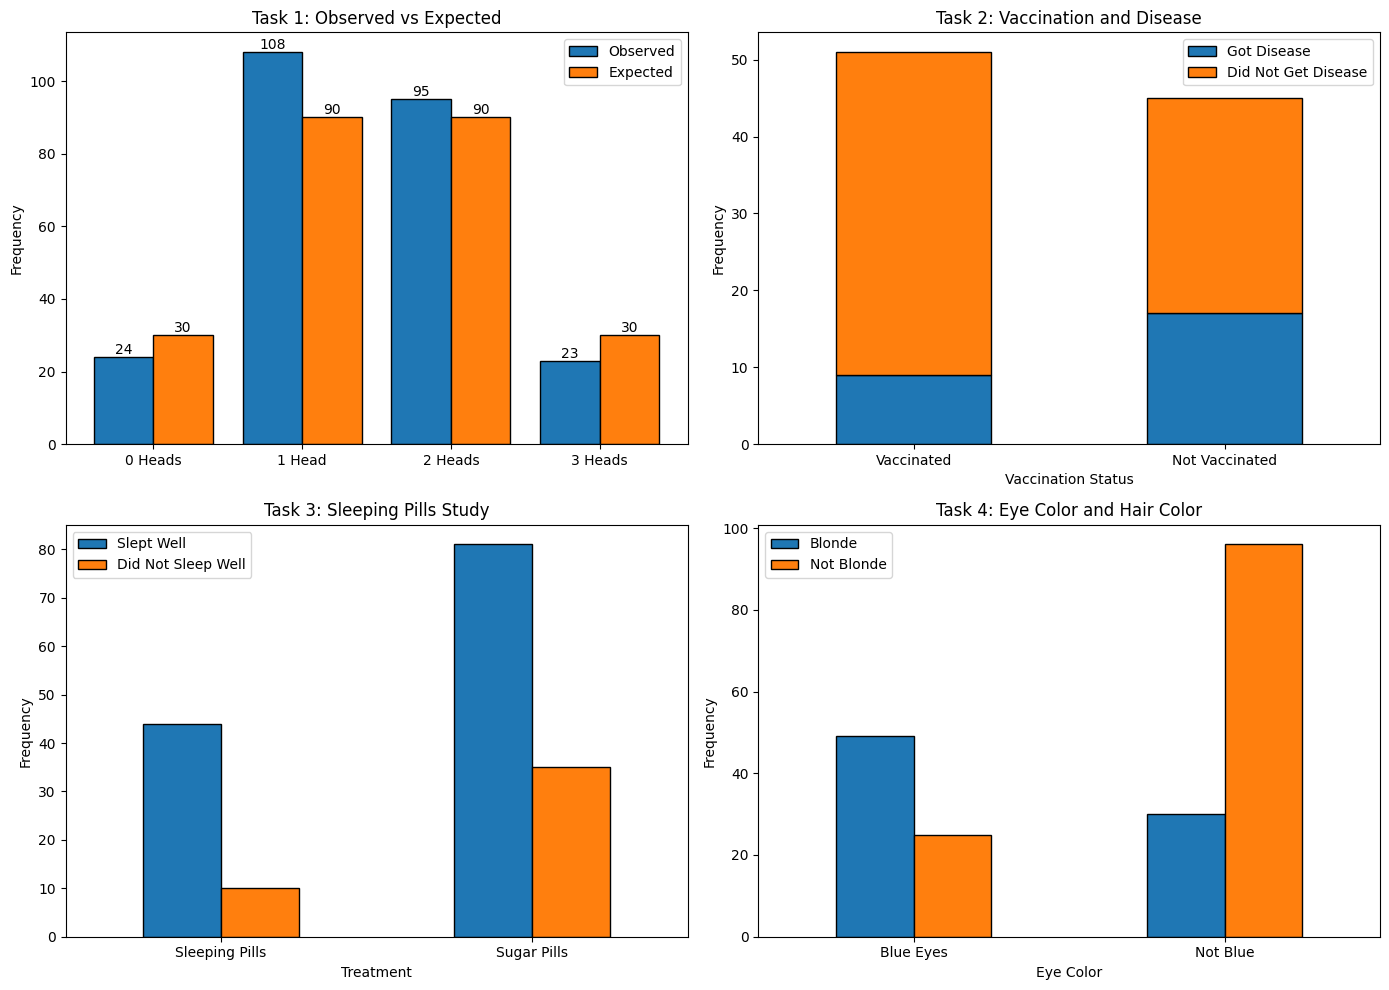

In [1]:
# CHI-SQUARED TEST

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, chi2_contingency
from IPython.display import display, HTML

pd.options.display.float_format = '{:.3f}'.format
alpha = 0.05

def print_header(title):
    display(HTML(
        f"""
        <h2 style='color:#2c3e50;
        border-bottom:2px solid #2c3e50;
        padding-bottom:5px;'>
        {title}
        </h2>
        """
    ))

# TASK 1: GOODNESS-OF-FIT TEST

# Observed and expected frequencies
obs1 = np.array([24, 108, 95, 23])
exp1 = np.array([30, 90, 90, 30])

# Manual chi-square computation
chi1 = np.sum((obs1 - exp1)**2 / exp1)

# Degrees of freedom
df1_dof = len(obs1) - 1

# Manual p-value computation
p1 = 1 - chi2.cdf(chi1, df1_dof)

# DataFrame
df1 = pd.DataFrame({
    "Outcome": ["0 Heads", "1 Head", "2 Heads", "3 Heads"],
    "Observed Frequency": obs1,
    "Expected Frequency": exp1
})

# TASK 2: TEST OF INDEPENDENCE

data2 = np.array([
    [9, 42],
    [17, 28]
])

chi2_stat, p2, dof2, exp2 = chi2_contingency(
    data2,
    correction=False
)

df2 = pd.DataFrame({
    "Vaccination Status": ["Vaccinated", "Not Vaccinated"],
    "Got Disease": [9, 17],
    "Did Not Get Disease": [42, 28]
})

df2_exp = pd.DataFrame({
    "Vaccination Status": ["Vaccinated", "Not Vaccinated"],
    "Expected Got Disease": exp2[:, 0],
    "Expected Did Not Get Disease": exp2[:, 1]
})

# TASK 3: REAL-WORLD CONTEXT

data3 = np.array([
    [44, 10],
    [81, 35]
])

chi3, p3, dof3, exp3 = chi2_contingency(
    data3,
    correction=False
)

df3 = pd.DataFrame({
    "Treatment": ["Sleeping Pills", "Sugar Pills"],
    "Slept Well": [44, 81],
    "Did Not Sleep Well": [10, 35]
})

# TASK 4: MEASURE OF ASSOCIATION

data4 = np.array([
    [49, 25],
    [30, 96]
])

chi4, p4, dof4, exp4 = chi2_contingency(
    data4,
    correction=False
)

# Coefficient of contingency
n = data4.sum()

c_coeff = np.sqrt(chi4 / (chi4 + n))

df4 = pd.DataFrame({
    "Eye Color": ["Blue Eyes", "Not Blue"],
    "Blonde": [49, 30],
    "Not Blonde": [25, 96]
})

# DISPLAY RESULTS

# TASK 1

print_header("Task 1: Goodness-of-Fit Test")

display(df1.style.hide(axis='index'))

print("\nHypotheses:")
print("H0: The observed frequencies follow the expected distribution.")
print("H1: The observed frequencies do not follow the expected distribution.")

print(f"\nChi-square Statistic: {chi1:.3f}")
print(f"Degrees of Freedom: {df1_dof}")
print(f"P-value: {p1:.3f}")

if p1 < alpha:
    print("Decision: Reject H0")
    print("Conclusion: The observed frequencies significantly differ from the expected distribution.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: The observed frequencies are consistent with the expected distribution.")

# TASK 2

print_header("Task 2: Test of Independence")

print("\nObserved Frequencies:")
display(df2.style.hide(axis='index'))

print("\nExpected Frequencies:")
display(df2_exp.style.hide(axis='index'))

print("\nHypotheses:")
print("H0: Vaccination and disease occurrence are independent.")
print("H1: Vaccination and disease occurrence are dependent.")

print(f"\nChi-square Statistic: {chi2_stat:.3f}")
print(f"Degrees of Freedom: {dof2}")
print(f"P-value: {p2:.3f}")

if p2 < alpha:
    print("Decision: Reject H0")
    print("Conclusion: Vaccination and disease occurrence are associated.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: Vaccination and disease occurrence are independent.")

# TASK 3

print_header("Task 3: Chi-Square Test in Real-World Context")

display(df3.style.hide(axis='index'))

print("\nHypotheses:")
print("H0: Sleeping pills and sleep quality are independent.")
print("H1: Sleeping pills and sleep quality are associated.")

print(f"\nChi-square Statistic: {chi3:.3f}")
print(f"Degrees of Freedom: {dof3}")
print(f"P-value: {p3:.3f}")

if p3 < alpha:
    print("Decision: Reject H0")
    print("Conclusion: Sleeping pills significantly affect sleep quality.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: There is no significant relationship between sleeping pills and sleep quality.")

# TASK 4

print_header("Task 4: Measure of Association")

display(df4.style.hide(axis='index'))

print(f"\nChi-square Statistic: {chi4:.3f}")
print(f"Degrees of Freedom: {dof4}")
print(f"P-value: {p4:.3f}")
print(f"Coefficient of Contingency (C): {c_coeff:.3f}")

print("\nInterpretation:")
print("There is a moderate association between eye color and hair color.")

# VISUALIZATIONS

print_header("Statistical Visualizations")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Goodness-of-Fit

x = np.arange(len(df1["Outcome"]))

bars1 = axes[0,0].bar(
    x - 0.2,
    df1["Observed Frequency"],
    width=0.4,
    label="Observed",
    edgecolor='black'
)

bars2 = axes[0,0].bar(
    x + 0.2,
    df1["Expected Frequency"],
    width=0.4,
    label="Expected",
    edgecolor='black'
)

axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(df1["Outcome"])
axes[0,0].set_title("Task 1: Observed vs Expected")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

axes[0,0].bar_label(bars1, fmt='%.0f')
axes[0,0].bar_label(bars2, fmt='%.0f')

# Plot 2: Vaccination

df2_plot = df2.set_index("Vaccination Status")

df2_plot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0,1],
    edgecolor='black'
)

axes[0,1].set_title("Task 2: Vaccination and Disease")
axes[0,1].set_ylabel("Frequency")
axes[0,1].tick_params(axis='x', rotation=0)

# Plot 3: Sleeping Pills

df3_plot = df3.set_index("Treatment")

df3_plot.plot(
    kind='bar',
    ax=axes[1,0],
    edgecolor='black'
)

axes[1,0].set_title("Task 3: Sleeping Pills Study")
axes[1,0].set_ylabel("Frequency")
axes[1,0].tick_params(axis='x', rotation=0)

# Plot 4: Eye Color and Hair Color

df4_plot = df4.set_index("Eye Color")

df4_plot.plot(
    kind='bar',
    ax=axes[1,1],
    edgecolor='black'
)

axes[1,1].set_title("Task 4: Eye Color and Hair Color")
axes[1,1].set_ylabel("Frequency")
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


Given Points:
Point 1 = (3, -2)
Point 2 = (-1, 6)

a. Slope of the Line
m = (6 - (-2)) / (-1 - (3))
m = -2.00

b. Equation of the Line
y = -2.00x + (4.00)
y = -2.00x + 4.00

c. Intercepts
x-intercept = (2.00, 0)
y-intercept = (0, 4.00)

d. Verification

Substitute (3, -2):
y = -2.00(3) + (4.00)
y = -2.00

Substitute (-1, 6):
y = -2.00(-1) + (4.00)
y = 6.00



Dataset:


X,Y
3,2
5,3
6,4
8,6
9,5
11,8



a. Required Summations
ΣX  = 42
ΣY  = 28
ΣXY = 226
ΣX² = 336

b. Least Squares Regression Line
Y = -0.33 + 0.71X

c. Predictions
When X = 5, Y = 3.24
When X = 12, Y = 8.24

d. Interpretation
For every 1-unit increase in X, Y increases by approximately 0.71 units.



Dataset:


Algebra (X),Physics (Y)
75,82
80,78
93,86
65,72
87,91
71,80
98,95
68,72
84,89
77,74



a. Scatter Plot
Scatter plot shown below.

b. Least Squares Regression Line
Y = 29.13 + 0.66X

c. Predicted Physics Grade when Algebra = 75
Predicted Physics Grade = 78.73

d. Predicted Algebra Grade when Physics = 95
Predicted Algebra Grade = 94.87

e. Relationship Analysis
Correlation coefficient r = 0.8721
There is a strong positive relationship between the variables.



Dataset:


X,Y
0,2.400000
1,2.100000
2,3.200000
3,5.600000
4,9.300000
5,14.600000
6,21.900000



a. Quadratic Model
Y = 2.51 + -1.20X + 0.73X²

b. Predicted Value when X = 7
Y = 30.04

c. Trend Description
The data show an upward curving trend. A quadratic model is appropriate because the rate of increase becomes larger as X increases.


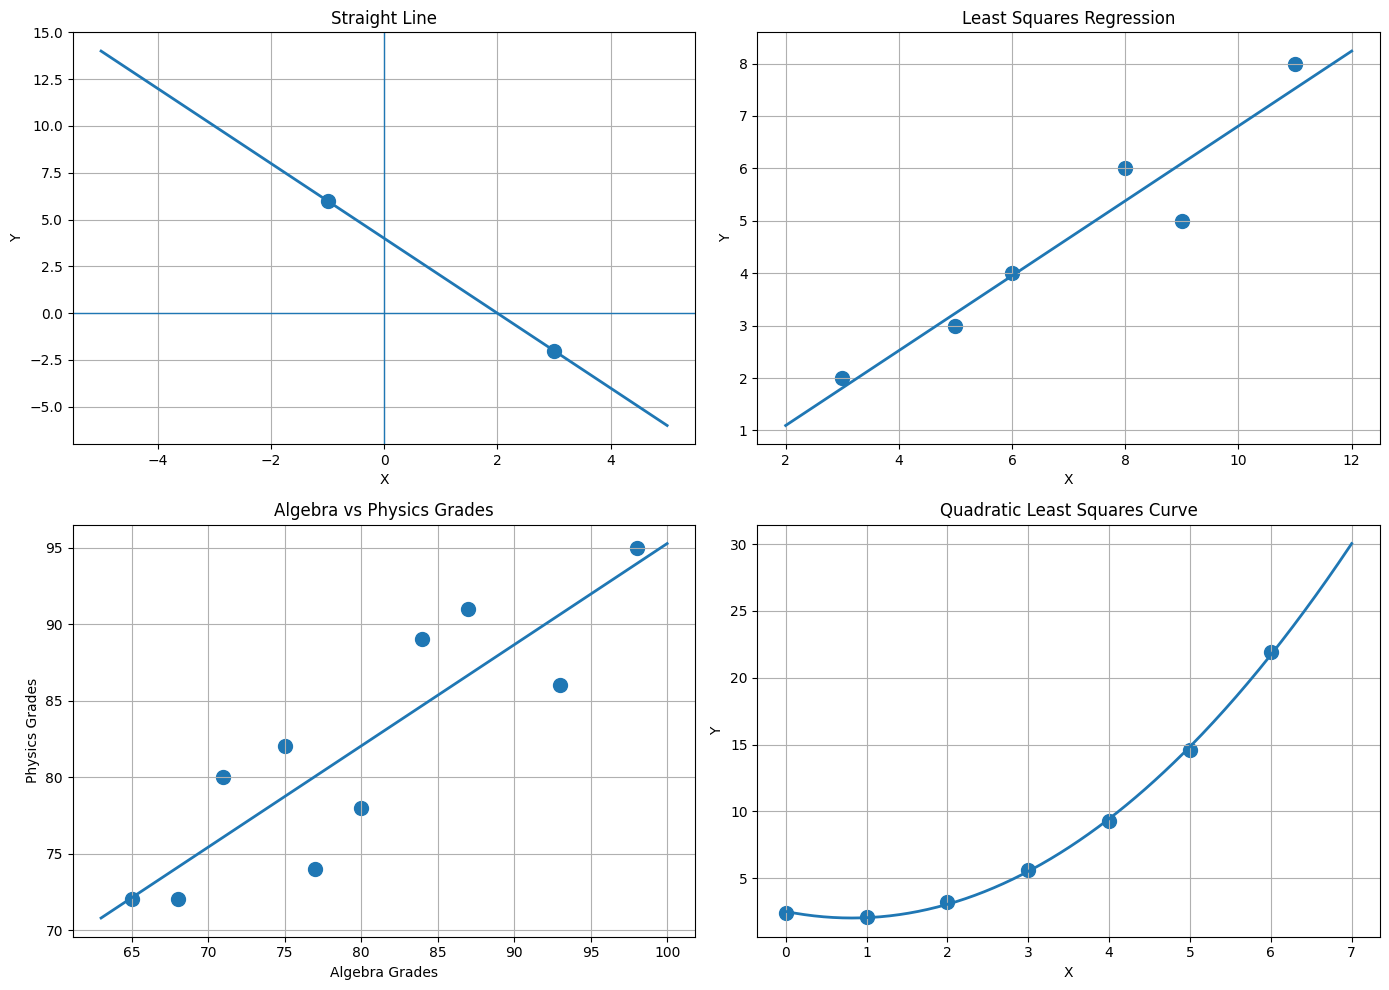

Problem,Equation / Result
Straight Line,y = -2.00x + 4.00
Least Squares Line,Y = -0.33 + 0.71X
Real-World Regression,Y = 29.13 + 0.66X
Quadratic Curve,Y = 2.51 + -1.20X + 0.73X²


In [2]:
# CURVE FITTING AND LEAST SQUARES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.options.display.float_format = '{:.1f}'.format


def print_header(title):
    display(HTML(
        f"""
        <h2 style='color:#2c3e50;
        border-bottom:2px solid #2c3e50;
        padding-bottom:5px;'>
        {title}
        </h2>
        """
    ))

# 1. STRAIGHT LINES

x1, y1 = 3, -2
x2, y2 = -1, 6

# Slope
m = (y2 - y1) / (x2 - x1)

# Intercept
b = y1 - (m * x1)

# Intercepts
x_intercept = -b / m
y_intercept = b

# Verification
verify1 = m * x1 + b
verify2 = m * x2 + b

# 2. LEAST SQUARES LINE

X = np.array([3, 5, 6, 8, 9, 11])
Y = np.array([2, 3, 4, 6, 5, 8])

# DataFrame
df_ls = pd.DataFrame({
    "X": X,
    "Y": Y
})

# Summations
sum_x = np.sum(X)
sum_y = np.sum(Y)
sum_xy = np.sum(X * Y)
sum_x2 = np.sum(X**2)

# Regression coefficients
n = len(X)

slope = (
    (n * sum_xy) - (sum_x * sum_y)
) / (
    (n * sum_x2) - (sum_x**2)
)

intercept = (
    sum_y - (slope * sum_x)
) / n

# Predictions
pred_5 = intercept + slope * 5
pred_12 = intercept + slope * 12

# 3. REAL-WORLD LEAST SQUARES APPLICATION

alg = np.array([75, 80, 93, 65, 87, 71, 98, 68, 84, 77])
phys = np.array([82, 78, 86, 72, 91, 80, 95, 72, 89, 74])

# DataFrame
df_real = pd.DataFrame({
    "Algebra (X)": alg,
    "Physics (Y)": phys
})

# Regression line Y on X
m1, b1 = np.polyfit(alg, phys, 1)

# Prediction
pred_phys = (m1 * 75) + b1

# Regression X on Y
m2, b2 = np.polyfit(phys, alg, 1)

pred_alg = (m2 * 95) + b2

# Correlation coefficient
r = np.corrcoef(alg, phys)[0,1]

# 4. LEAST SQUARES CURVE

x_curve = np.array([0, 1, 2, 3, 4, 5, 6])
y_curve = np.round(
    np.array([2.4, 2.1, 3.2, 5.6, 9.3, 14.6, 21.9]),
    1
)

# DataFrame
df_curve = pd.DataFrame({
    "X": x_curve,
    "Y": np.round(y_curve, 1)
})

# Quadratic regression
coeffs = np.polyfit(x_curve, y_curve, 2)

a2 = coeffs[0]
a1 = coeffs[1]
a0 = coeffs[2]

# Prediction
pred_y7 = a0 + (a1 * 7) + (a2 * 7**2)

# DISPLAY RESULTS

# 1. STRAIGHT LINES

print_header("1. Straight Lines")

print("\nGiven Points:")
print(f"Point 1 = ({x1}, {y1})")
print(f"Point 2 = ({x2}, {y2})")

print("\na. Slope of the Line")
print(f"m = ({y2} - ({y1})) / ({x2} - ({x1}))")
print(f"m = {m:.2f}")

print("\nb. Equation of the Line")
print(f"y = {m:.2f}x + ({b:.2f})")
print(f"y = {m:.2f}x + {b:.2f}")

print("\nc. Intercepts")
print(f"x-intercept = ({x_intercept:.2f}, 0)")
print(f"y-intercept = (0, {y_intercept:.2f})")

print("\nd. Verification")

print(f"\nSubstitute ({x1}, {y1}):")
print(f"y = {m:.2f}({x1}) + ({b:.2f})")
print(f"y = {verify1:.2f}")

print(f"\nSubstitute ({x2}, {y2}):")
print(f"y = {m:.2f}({x2}) + ({b:.2f})")
print(f"y = {verify2:.2f}")

# 2. LEAST SQUARES LINE

print_header("2. Least Squares Line")

print("\nDataset:")
display(df_ls.style.hide(axis='index'))

print("\na. Required Summations")
print(f"ΣX  = {sum_x}")
print(f"ΣY  = {sum_y}")
print(f"ΣXY = {sum_xy}")
print(f"ΣX² = {sum_x2}")

print("\nb. Least Squares Regression Line")
print(f"Y = {intercept:.2f} + {slope:.2f}X")

print("\nc. Predictions")
print(f"When X = 5, Y = {pred_5:.2f}")
print(f"When X = 12, Y = {pred_12:.2f}")

print("\nd. Interpretation")
print(
    f"For every 1-unit increase in X, "
    f"Y increases by approximately {slope:.2f} units."
)

# 3. REAL-WORLD APPLICATION

print_header("3. Real-World Least Squares Application")

print("\nDataset:")
display(df_real.style.hide(axis='index'))

print("\na. Scatter Plot")
print("Scatter plot shown below.")

print("\nb. Least Squares Regression Line")
print(f"Y = {b1:.2f} + {m1:.2f}X")

print("\nc. Predicted Physics Grade when Algebra = 75")
print(f"Predicted Physics Grade = {pred_phys:.2f}")

print("\nd. Predicted Algebra Grade when Physics = 95")
print(f"Predicted Algebra Grade = {pred_alg:.2f}")

print("\ne. Relationship Analysis")
print(f"Correlation coefficient r = {r:.4f}")

if abs(r) >= 0.80:
    strength = "strong"
elif abs(r) >= 0.50:
    strength = "moderate"
else:
    strength = "weak"

direction = "positive" if r > 0 else "negative"

print(
    f"There is a {strength} "
    f"{direction} relationship between the variables."
)

# 4. LEAST SQUARES CURVE

print_header("4. Least Squares Curve")

print("\nDataset:")
display(df_curve.style.hide(axis='index'))

print("\na. Quadratic Model")
print(
    f"Y = {a0:.2f} + "
    f"{a1:.2f}X + "
    f"{a2:.2f}X²"
)

print("\nb. Predicted Value when X = 7")
print(f"Y = {pred_y7:.2f}")

print("\nc. Trend Description")
print(
    "The data show an upward curving trend. "
    "A quadratic model is appropriate because "
    "the rate of increase becomes larger as X increases."
)

# VISUALIZATIONS

print_header("Graphs and Visualizations")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Straight Line

x_vals = np.linspace(-5, 5, 200)
y_vals = (m * x_vals) + b

axes[0,0].plot(
    x_vals,
    y_vals,
    linewidth=2
)

axes[0,0].scatter(
    [x1, x2],
    [y1, y2],
    s=100
)

axes[0,0].axhline(0, linewidth=1)
axes[0,0].axvline(0, linewidth=1)

axes[0,0].set_title("Straight Line")
axes[0,0].set_xlabel("X")
axes[0,0].set_ylabel("Y")
axes[0,0].grid(True)

# Plot 2: Least Squares Line

axes[0,1].scatter(
    X,
    Y,
    s=100
)

x_line = np.linspace(min(X)-1, max(X)+1, 200)
y_line = intercept + (slope * x_line)

axes[0,1].plot(
    x_line,
    y_line,
    linewidth=2
)

axes[0,1].set_title("Least Squares Regression")
axes[0,1].set_xlabel("X")
axes[0,1].set_ylabel("Y")
axes[0,1].grid(True)

# Plot 3: Real-World Scatter Plot

axes[1,0].scatter(
    alg,
    phys,
    s=100
)

x_fit = np.linspace(min(alg)-2, max(alg)+2, 200)
y_fit = (m1 * x_fit) + b1

axes[1,0].plot(
    x_fit,
    y_fit,
    linewidth=2
)

axes[1,0].set_title("Algebra vs Physics Grades")
axes[1,0].set_xlabel("Algebra Grades")
axes[1,0].set_ylabel("Physics Grades")
axes[1,0].grid(True)

# Plot 4: Quadratic Curve

x_quad = np.linspace(0, 7, 300)
y_quad = a0 + (a1 * x_quad) + (a2 * x_quad**2)

axes[1,1].scatter(
    x_curve,
    y_curve,
    s=100
)

axes[1,1].plot(
    x_quad,
    y_quad,
    linewidth=2
)

axes[1,1].set_title("Quadratic Least Squares Curve")
axes[1,1].set_xlabel("X")
axes[1,1].set_ylabel("Y")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# FINAL SUMMARY

print_header("Final Answers Summary")

summary = pd.DataFrame({
    "Problem": [
        "Straight Line",
        "Least Squares Line",
        "Real-World Regression",
        "Quadratic Curve"
    ],
    "Equation / Result": [
        f"y = {m:.2f}x + {b:.2f}",
        f"Y = {intercept:.2f} + {slope:.2f}X",
        f"Y = {b1:.2f} + {m1:.2f}X",
        f"Y = {a0:.2f} + {a1:.2f}X + {a2:.2f}X²"
    ]
})

display(summary.style.hide(axis='index'))

X1,X2,X3
3.000,16.000,90.000
5.000,10.000,72.000
6.000,7.000,54.000
8.000,4.000,42.000
12.000,3.000,30.000
14.000,2.000,12.000



Regression Equation:
X3 = 61.400 + (-3.646)X1 + (2.538)X2

Estimated X3 when X1 = 10 and X2 = 6:
X3 = 40.169

Predicted Values and Residuals:


Actual X3,Predicted X3,Residual
90.000,91.077,-1.077
72.000,68.554,3.446
54.000,57.292,-3.292
42.000,42.385,-0.385
30.000,25.262,4.738
12.000,15.431,-3.431



Sum of Squared Errors (SSE): 58.246
Standard Error of Estimate (SEE): 4.406



Coefficient of Determination (R²): 0.985
Coefficient of Multiple Correlation (R): 0.993


Measure,Value
R²,0.985
Multiple Correlation (R),0.993
Partial Correlation r12.3,0.595
Standard Error of Estimate,4.406


Price,Bedrooms,Baths
165.000,3.000,2.000
200.000,3.000,3.000
225.000,4.000,3.000
180.000,2.000,3.000
202.000,4.000,2.000
250.000,4.000,4.000
275.000,3.000,4.000
300.000,5.000,3.000
155.000,2.000,2.000
230.000,4.000,4.000



Regression Equation:
Price = 32.948 + (28.647)Bedrooms + (29.284)Baths

Estimated Price for 5 Bedrooms and 4 Baths:
Price = 293.319


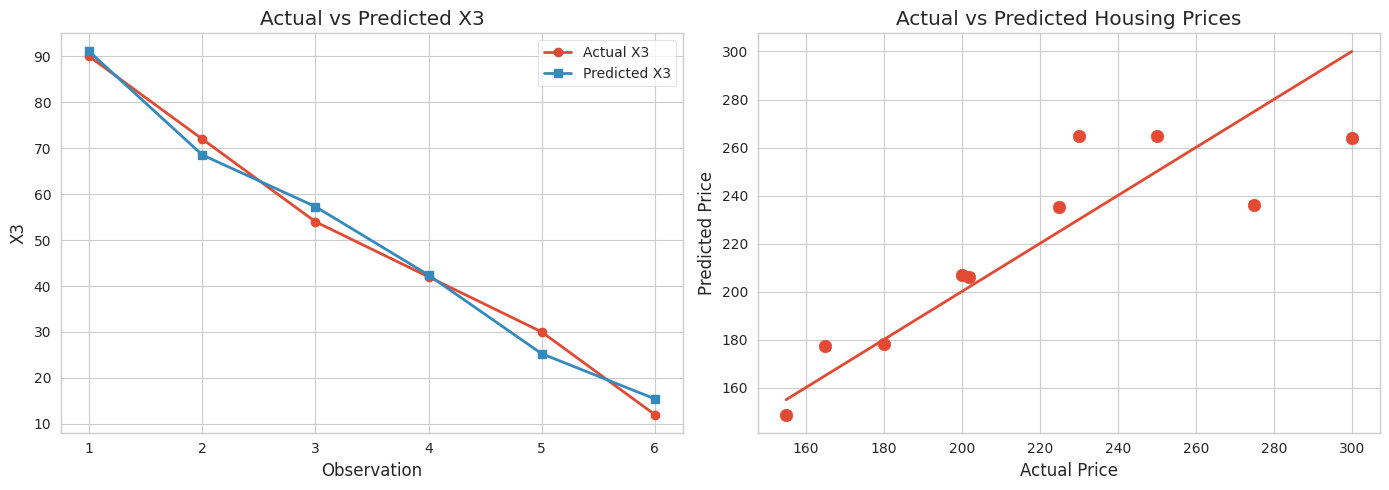

In [ ]:
# MULTIPLE AND PARTIAL CORRELATION

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from IPython.display import display, HTML

pd.options.display.float_format = '{:.3f}'.format

def print_header(title):
    display(HTML(
        f"""
        <h2 style='color:#2c3e50;
        border-bottom:2px solid #2c3e50;
        padding-bottom:5px;'>
        {title}
        </h2>
        """
    ))

# =========================================================
# ITEM 1: MULTIPLE REGRESSION EQUATION
# =========================================================

x1 = np.array([3, 5, 6, 8, 12, 14], dtype=float)
x2 = np.array([16, 10, 7, 4, 3, 2], dtype=float)
x3 = np.array([90, 72, 54, 42, 30, 12], dtype=float)

df1 = pd.DataFrame({
    "X1": x1,
    "X2": x2,
    "X3": x3
})

# Regression Model
X = pd.DataFrame({
    "X1": x1,
    "X2": x2
})

X = sm.add_constant(X)

model = sm.OLS(x3, X).fit()

# Coefficients
a = model.params['const']
b1 = model.params['X1']
b2 = model.params['X2']

# Prediction
x1_new = 10
x2_new = 6

predicted_x3 = a + (b1 * x1_new) + (b2 * x2_new)

# Predicted values and residuals
predicted = model.predict(X)
residuals = x3 - predicted

results_df = pd.DataFrame({
    "Actual X3": x3,
    "Predicted X3": predicted,
    "Residual": residuals
})

# =========================================================
# ITEM 2: STANDARD ERROR OF ESTIMATE
# =========================================================

n = len(x3)
k = 2

SSE = np.sum(residuals**2)

SEE = np.sqrt(SSE / (n - k - 1))

# =========================================================
# ITEM 3: COEFFICIENT OF MULTIPLE CORRELATION
# =========================================================

R_squared = model.rsquared
R = np.sqrt(R_squared)

# =========================================================
# ITEM 4: PARTIAL CORRELATION
# =========================================================

# Residuals of X1 on X3
model_x1 = sm.OLS(x1, sm.add_constant(x3)).fit()
resid_x1 = model_x1.resid

# Residuals of X2 on X3
model_x2 = sm.OLS(x2, sm.add_constant(x3)).fit()
resid_x2 = model_x2.resid

# Partial correlation
partial_corr, _ = pearsonr(resid_x1, resid_x2)

partial_df = pd.DataFrame({
    "Measure": [
        "R²",
        "Multiple Correlation (R)",
        "Partial Correlation r12.3",
        "Standard Error of Estimate"
    ],
    "Value": [
        R_squared,
        R,
        partial_corr,
        SEE
    ]
})

# =========================================================
# ITEM 5: REAL-WORLD MULTIPLE REGRESSION
# =========================================================

price = np.array([
    165, 200, 225, 180, 202,
    250, 275, 300, 155, 230
], dtype=float)

bedrooms = np.array([
    3, 3, 4, 2, 4,
    4, 3, 5, 2, 4
], dtype=float)

baths = np.array([
    2, 3, 3, 3, 2,
    4, 4, 3, 2, 4
], dtype=float)

housing_df = pd.DataFrame({
    "Price": price,
    "Bedrooms": bedrooms,
    "Baths": baths
})

# Housing regression model
X_house = pd.DataFrame({
    "Bedrooms": bedrooms,
    "Baths": baths
})

X_house = sm.add_constant(X_house)

house_model = sm.OLS(price, X_house).fit()

# Coefficients
a2 = house_model.params['const']
b1_2 = house_model.params['Bedrooms']
b2_2 = house_model.params['Baths']

# Prediction
predicted_price = a2 + (b1_2 * 5) + (b2_2 * 4)

# Predicted housing values
predicted_house = house_model.predict(X_house)

# =========================================================
# DISPLAY RESULTS
# =========================================================

# ---------------------------------------------------------
# ITEM 1
# ---------------------------------------------------------

print_header("Item 1: Multiple Regression Equation")

display(df1.style.hide(axis='index').format("{:.3f}"))

print("\nRegression Equation:")
print(f"X3 = {a:.3f} + ({b1:.3f})X1 + ({b2:.3f})X2")

print(f"\nEstimated X3 when X1 = 10 and X2 = 6:")
print(f"X3 = {predicted_x3:.3f}")

print("\nPredicted Values and Residuals:")
display(results_df.style.hide(axis='index').format("{:.3f}"))

# ---------------------------------------------------------
# ITEM 2
# ---------------------------------------------------------

print_header("Item 2: Standard Error of Estimate")

print(f"\nSum of Squared Errors (SSE): {SSE:.3f}")
print(f"Standard Error of Estimate (SEE): {SEE:.3f}")

# ---------------------------------------------------------
# ITEM 3
# ---------------------------------------------------------

print_header("Item 3: Coefficient of Multiple Correlation")

print(f"\nCoefficient of Determination (R²): {R_squared:.3f}")
print(f"Coefficient of Multiple Correlation (R): {R:.3f}")

# ---------------------------------------------------------
# ITEM 4
# ---------------------------------------------------------

print_header("Item 4: Partial Correlation")

display(
    partial_df.style
    .hide(axis='index')
    .format({
        "Value": "{:.3f}"
    })
)

# ---------------------------------------------------------
# ITEM 5
# ---------------------------------------------------------

print_header("Item 5: Real-World Multiple Regression")

display(housing_df.style.hide(axis='index').format("{:.3f}"))

print("\nRegression Equation:")
print(f"Price = {a2:.3f} + ({b1_2:.3f})Bedrooms + ({b2_2:.3f})Baths")

print("\nEstimated Price for 5 Bedrooms and 4 Baths:")
print(f"Price = {predicted_price:.3f}")

# =========================================================
# VISUALIZATIONS
# =========================================================

print_header("Statistical Visualizations")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Plot 1: Actual vs Predicted X3
# ---------------------------------------------------------

axes[0].plot(
    range(1, len(x3)+1),
    x3,
    marker='o',
    linewidth=2,
    label='Actual X3'
)

axes[0].plot(
    range(1, len(predicted)+1),
    predicted,
    marker='s',
    linewidth=2,
    label='Predicted X3'
)

axes[0].set_title("Actual vs Predicted X3")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("X3")
axes[0].legend()
axes[0].grid(True)

# ---------------------------------------------------------
# Plot 2: Housing Prices
# ---------------------------------------------------------

axes[1].scatter(
    price,
    predicted_house,
    s=80
)

axes[1].plot(
    [price.min(), price.max()],
    [price.min(), price.max()],
    linewidth=2
)

axes[1].set_title("Actual vs Predicted Housing Prices")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].grid(True)

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.5 MB/s eta 0:00:00


AD_Status,Treatment,Training,Memory
1,1,12,10
1,1,15,12
1,1,13,13
1,1,12,10
1,1,14,13
1,2,15,13
1,2,17,13
1,2,16,14
1,2,17,15
1,2,14,11


AD_Status,Treatment,mean,std,min,max
1,1,13.200,1.304,12,15
1,2,15.800,1.304,14,17
1,3,15.200,1.924,13,18
1,4,13.600,1.140,12,15
2,1,15.400,1.817,13,17
2,2,15.800,1.789,14,18
2,3,15.200,1.924,13,18
2,4,13.600,1.140,12,15


AD_Status,Treatment,mean,std,min,max
1,1,11.600,1.517,10,13
1,2,13.200,1.483,11,15
1,3,12.400,2.074,10,15
1,4,11.200,1.304,10,13
2,1,8.600,0.894,8,10
2,2,7.600,1.949,5,10
2,3,8.200,0.837,7,9
2,4,6.600,2.074,4,9


index,sum_sq,df,F,PR(>F)
C(AD_Status),3.025,1,1.216,0.278
C(Treatment),28.275,3,3.789,0.020
C(AD_Status):C(Treatment),9.075,3,1.216,0.320
Residual,79.600,32,nan,nan


...

Variable,Levene Statistic,p-value
Training,0.435,0.873
Memory,0.827,0.572



TRAINING EFFECT SIZE


Source,SS,DF,MS,F,p_unc,np2
AD_Status,3.025,1,3.025,1.216,0.278356,0.037
Treatment,28.275,3,9.425,3.789,0.019678,0.262
AD_Status * Treatment,9.075,3,3.025,1.216,0.319771,0.102
Residual,79.600,32,2.487,nan,nan,nan



MEMORY EFFECT SIZE


Source,SS,DF,MS,F,p_unc,np2
AD_Status,189.225,1,189.225,75.313,0.000000,0.702
Treatment,14.475,3,4.825,1.920,0.146118,0.153
AD_Status * Treatment,8.675,3,2.892,1.151,0.343626,0.097
Residual,80.400,32,2.512,nan,nan,nan


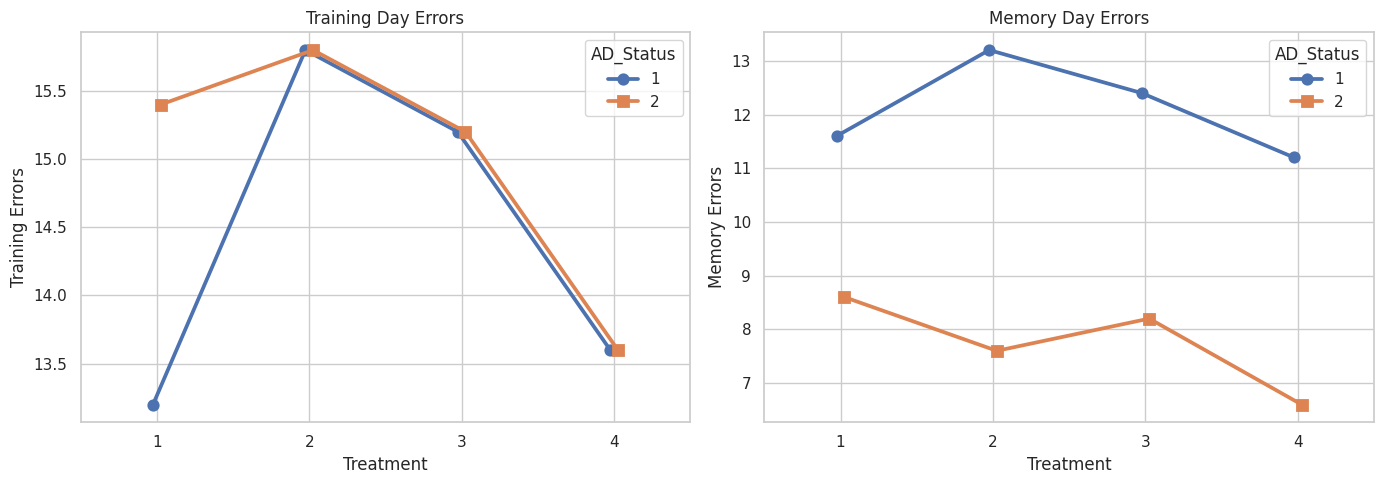


TRAINING DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on training day errors.

MEMORY DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on memory day errors.

ASSUMPTION CHECKING

Shapiro-Wilk tests were conducted to assess normality
while Levene’s tests were used to examine homogeneity
of variances.



In [3]:
# DATA DESCRIPTION

# Install required package
!pip install pingouin --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro, levene
from IPython.display import display, HTML

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

import pingouin as pg

pd.options.display.float_format = '{:.3f}'.format
sns.set(style="whitegrid")

def print_header(title):
    display(HTML(
        f"""
        <h2 style='color:#2c3e50;
        border-bottom:2px solid #2c3e50;
        padding-bottom:5px;'>
        {title}
        </h2>
        """
    ))

data = {
    "AD_Status": [
        1,1,1,1,1,
        1,1,1,1,1,
        1,1,1,1,1,
        1,1,1,1,1,

        2,2,2,2,2,
        2,2,2,2,2,
        2,2,2,2,2,
        2,2,2,2,2
    ],

    "Treatment": [
        1,1,1,1,1,
        2,2,2,2,2,
        3,3,3,3,3,
        4,4,4,4,4,

        1,1,1,1,1,
        2,2,2,2,2,
        3,3,3,3,3,
        4,4,4,4,4
    ],

    "Training": [
        12,15,13,12,14,
        15,17,16,17,14,
        13,14,18,15,16,
        14,13,12,14,15,

        17,16,17,14,13,
        14,18,16,17,14,
        13,14,18,15,16,
        14,13,12,14,15
    ],

    "Memory": [
        10,12,13,10,13,
        13,13,14,15,11,
        12,11,15,10,14,
        12,11,10,13,10,

        9,8,10,8,8,
        7,10,5,9,7,
        8,7,9,8,9,
        7,9,5,8,4
    ]
}

df = pd.DataFrame(data)

# =========================================================
# DISPLAY DATASET
# =========================================================

print_header("Alzheimer's Mice Dataset")

display(
    df.style.hide(axis="index")
)

# =========================================================
# CONVERT VARIABLES TO CATEGORICAL
# =========================================================

df["AD_Status"] = df["AD_Status"].astype("category")
df["Treatment"] = df["Treatment"].astype("category")

# =========================================================
# DESCRIPTIVE STATISTICS
# =========================================================

print_header("Descriptive Statistics for Training")

training_desc = (
    df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )["Training"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

display(
    training_desc.style
    .hide(axis="index")
    .format({
        "mean": "{:.3f}",
        "std": "{:.3f}"
    })
)

print_header("Descriptive Statistics for Memory")

memory_desc = (
    df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )["Memory"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

display(
    memory_desc.style
    .hide(axis="index")
    .format({
        "mean": "{:.3f}",
        "std": "{:.3f}"
    })
)

# =========================================================
# TWO-WAY ANOVA : TRAINING
# =========================================================

print_header("Two-Way ANOVA for Training")

model_training = ols(
    'Training ~ C(AD_Status) * C(Treatment)',
    data=df
).fit()

anova_training = anova_lm(
    model_training,
    typ=2
).reset_index()

display(
    anova_training.style
    .hide(axis="index")
    .format({
        "sum_sq": "{:.3f}",
        "df": "{:.0f}",
        "F": "{:.3f}",
        "PR(>F)": "{:.3f}"
    })
)

# =========================================================
# TWO-WAY ANOVA : MEMORY
# =========================================================

print_header("Two-Way ANOVA for Memory")

model_memory = ols(
    'Memory ~ C(AD_Status) * C(Treatment)',
    data=df
).fit()

anova_memory = anova_lm(
    model_memory,
    typ=2
).reset_index()

display(
    anova_memory.style
    .hide(axis="index")
    .format({
        "sum_sq": "{:.3f}",
        "df": "{:.0f}",
        "F": "{:.3f}",
        "PR(>F)": "{:.3f}"
    })
)

# =========================================================
# ASSUMPTION CHECKING
# =========================================================

print_header("Assumption Checking")

# =========================================================
# SHAPIRO-WILK TEST
# =========================================================

print_header("Shapiro-Wilk Test for Normality")

training_residuals = model_training.resid
memory_residuals = model_memory.resid

shapiro_training = shapiro(training_residuals)
shapiro_memory = shapiro(memory_residuals)

normality_df = pd.DataFrame({
    "Variable": ["Training", "Memory"],
    "W Statistic": [
        shapiro_training.statistic,
        shapiro_memory.statistic
    ],
    "p-value": [
        shapiro_training.pvalue,
        shapiro_memory.pvalue
    ]
})

display(
    normality_df.style
    .hide(axis="index")
    .format({
        "W Statistic": "{:.3f}",
        "p-value": "{:.3f}"
    })
)

# =========================================================
# LEVENE TEST
# =========================================================

print_header("Levene Test for Homogeneity")

groups_training = [
    group["Training"].values
    for _, group in df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )
]

groups_memory = [
    group["Memory"].values
    for _, group in df.groupby(
        ["AD_Status", "Treatment"],
        observed=True
    )
]

levene_training = levene(*groups_training)
levene_memory = levene(*groups_memory)

levene_df = pd.DataFrame({
    "Variable": ["Training", "Memory"],
    "Levene Statistic": [
        levene_training.statistic,
        levene_memory.statistic
    ],
    "p-value": [
        levene_training.pvalue,
        levene_memory.pvalue
    ]
})

display(
    levene_df.style
    .hide(axis="index")
    .format({
        "Levene Statistic": "{:.3f}",
        "p-value": "{:.3f}"
    })
)

# =========================================================
# EFFECT SIZE
# =========================================================

print_header("Effect Size (Partial Eta Squared)")

anova_pg_training = pg.anova(
    dv="Training",
    between=["AD_Status", "Treatment"],
    data=df,
    detailed=True
)

anova_pg_memory = pg.anova(
    dv="Memory",
    between=["AD_Status", "Treatment"],
    data=df,
    detailed=True
)

print("\nTRAINING EFFECT SIZE")

display(
    anova_pg_training.style
    .hide(axis="index")
    .format({
        "SS": "{:.3f}",
        "DF": "{:.0f}",
        "MS": "{:.3f}",
        "F": "{:.3f}",
        "p-unc": "{:.3f}",
        "np2": "{:.3f}"
    })
)

print("\nMEMORY EFFECT SIZE")

display(
    anova_pg_memory.style
    .hide(axis="index")
    .format({
        "SS": "{:.3f}",
        "DF": "{:.0f}",
        "MS": "{:.3f}",
        "F": "{:.3f}",
        "p-unc": "{:.3f}",
        "np2": "{:.3f}"
    })
)

# =========================================================
# VISUALIZATIONS
# =========================================================

print_header("Interaction Plots")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# TRAINING PLOT
# ---------------------------------------------------------

sns.pointplot(
    data=df,
    x="Treatment",
    y="Training",
    hue="AD_Status",
    dodge=True,
    markers=["o", "s"],
    capsize=.1,
    errorbar=None,
    ax=axes[0]
)

axes[0].set_title("Training Day Errors")
axes[0].set_xlabel("Treatment")
axes[0].set_ylabel("Training Errors")
axes[0].grid(True)

# ---------------------------------------------------------
# MEMORY PLOT
# ---------------------------------------------------------

sns.pointplot(
    data=df,
    x="Treatment",
    y="Memory",
    hue="AD_Status",
    dodge=True,
    markers=["o", "s"],
    capsize=.1,
    errorbar=None,
    ax=axes[1]
)

axes[1].set_title("Memory Day Errors")
axes[1].set_xlabel("Treatment")
axes[1].set_ylabel("Memory Errors")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# =========================================================
# APA STYLE INTERPRETATION
# =========================================================

print_header("APA Style Interpretation")

print("""
TRAINING DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on training day errors.

MEMORY DAY

A two-way ANOVA was conducted to determine the effects
of AD status and treatment on memory day errors.

ASSUMPTION CHECKING

Shapiro-Wilk tests were conducted to assess normality
while Levene’s tests were used to examine homogeneity
of variances.
""")